In [42]:
import importlib.util

In [83]:
spec = importlib.util.spec_from_file_location("playing_style", "01_playing_style.py")
playing_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(playing_style)

spec = importlib.util.spec_from_file_location("production", "02_production.py")
production = importlib.util.module_from_spec(spec)
spec.loader.exec_module(production)

spec = importlib.util.spec_from_file_location("effectiveness", "03_effectiveness.py")
effectiveness = importlib.util.module_from_spec(spec)
spec.loader.exec_module(effectiveness)

spec = importlib.util.spec_from_file_location("usage", "04_usage.py")
usage = importlib.util.module_from_spec(spec)
spec.loader.exec_module(usage)

spec = importlib.util.spec_from_file_location("trajectory", "05_trajectory.py")
trajectory = importlib.util.module_from_spec(spec)
spec.loader.exec_module(trajectory)

spec = importlib.util.spec_from_file_location("contract", "06_contract.py")
contract = importlib.util.module_from_spec(spec)
spec.loader.exec_module(contract)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/robpacey/Projects/9. Pacey32 Agency/pacey32_agency/comparisonmodel/06_contract.py'

In [53]:
#playing_style.find_playing_style_comparables(8484153, 10)
#production.find_production_comparables(8484153, 10)
#effectiveness.find_effectiveness_comparables(8484153, 10)
#usage.find_usage_comparables(8484153, 10)
#trajectory.find_trajectory_comparables(8484153, 10)
contract.find_contract_comparables(8484153, 15)

,rank,playerId,player,position,season,games_played,goals,assists,points,goals_per_game,...,season_to,cap_hit,term,total_value,pct_cap_contract_start,signing_status,expiry_status,signed_date,production_gap,contract_relevance
0,1,8481528,Dylan Cozens,C,20222023,81,32,37,69,0.395,...,2029-30,7100000,7,49700000,8.50,RFA,UFA,2023-02-07,0,73.033932
1,2,8475172,Nazem Kadri,C,20122013,48,18,26,44,0.375,...,2014-15,2900000,2,5800000,4.51,RFA,RFA,2013-09-10,0,72.842233
2,3,8478427,Sebastian Aho,C,20182019,82,31,53,84,0.378,...,2023-24,8459000,5,42295000,10.37,RFA,UFA,2019-07-01,0,71.755808
3,4,8484153,Leo Carlsson,C,20252026,70,30,39,69,0.429,...,2030-31,18000000,5,90000000,17.31,RFA,UFA,2026-07-03,0,71.653131
4,5,8482740,Wyatt Johnston,C,20242025,82,35,38,73,0.427,...,2029-30,8400000,5,42000000,8.80,RFA,UFA,2025-03-07,0,71.362851
5,6,8480012,Elias Pettersson,C,20202021,26,10,11,21,0.385,...,2023-24,7350000,3,22050000,9.02,RFA,RFA,2021-10-01,0,58.51519
6,7,8475168,Matt Duchene,C,20132014,71,23,47,70,0.324,...,2018-19,6000000,5,30000000,8.70,RFA,UFA,2013-07-18,0,57.980874
7,8,8484144,Connor Bedard,C,20252026,69,31,45,76,0.449,...,2030-31,15000000,5,75000000,14.42,RFA,UFA,2026-07-18,0,54.019959
8,9,8481533,Trevor Zegras,C,20222023,81,23,44,67,0.284,...,2025-26,5750000,3,17250000,6.89,RFA,RFA,2023-10-02,0,52.487444
9,10,8477934,Leon Draisaitl,C,20162017,82,29,48,77,0.354,...,2024-25,8500000,8,68000000,11.33,RFA,UFA,2017-08-16,0,52.104983


In [57]:
#display(playing_style.explain_playing_style(
#        8484153,  # Leo Carlsson
#        8477951   # Nick Schmaltz
#    )
#)

#display(production.explain_production(
#        8484153,  # Leo Carlsson
#        8476459   # Mika Zibanejad
#    )
#)

#display(effectiveness.explain_effectiveness(
#        8484153,  # Leo Carlsson
#        8478403   # Jack Eichel
#    )
#)

#display(usage.explain_usage(
#        8484153,  # Leo Carlsson
#        8475798   # Jack Eichel
#    )
#)


In [58]:
contract.contract_market_summary(8484153, 15)

,metric,value
0,Comparable contracts,1.500000e+01
1,Weighted cap hit,8.324791e+06
2,Weighted term,5.120254e+00
3,Weighted total value,4.367259e+07
4,Weighted % of cap,9.675803e+00


In [62]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from sklearn.preprocessing import StandardScaler

client = bigquery.Client(project="pacey32-agency")

PRODUCTION_FEATURES = [
    "goals_per_game",
    "assists_per_game",
    "points_per_game",
    "goals_per_60",
    "assists_per_60",
    "points_per_60"
]

MIN_GAMES = 20
MIN_COMPS = 5
MAX_COMPS = 15


# =========================================================
# 1. LOAD HISTORICAL PLAYER PRODUCTION
# =========================================================

production = client.query(f"""
SELECT
    SAFE_CAST(p.playerId AS INT64) AS playerId,
    ANY_VALUE(p.player_name) AS player,
    ANY_VALUE(p.position) AS position,
    s.season,
    s.games_played,
    s.goals,
    s.assists,
    s.points,
    s.goals_per_game,
    s.assists_per_game,
    s.points_per_game,
    s.goals_per_60,
    s.assists_per_60,
    s.points_per_60
FROM `pacey32-agency.Comparison.01_PlayerProfile` p
INNER JOIN `pacey32-agency.Comparison.03_PlayerSeasonStats` s
    ON SAFE_CAST(p.playerId AS INT64) = SAFE_CAST(s.playerId AS INT64)
WHERE s.seasonPart = 'RegularSeason'
  AND s.games_played >= {MIN_GAMES}
GROUP BY
    p.playerId,
    s.season,
    s.games_played,
    s.goals,
    s.assists,
    s.points,
    s.goals_per_game,
    s.assists_per_game,
    s.points_per_game,
    s.goals_per_60,
    s.assists_per_60,
    s.points_per_60
""").to_dataframe()

production["season_start_year"] = production["season"].astype(str).str[:4].astype(int)


# =========================================================
# 2. LOAD HISTORICAL CONTRACTS
# =========================================================

contracts = client.query("""
SELECT
    player,
    position,
    contract_number,
    season_from,
    season_to,
    cap_hit,
    term,
    total_value,
    signing_status,
    signing_age,
    expiry_status,
    signed_date,
    pct_cap_contract_start
FROM `pacey32-agency.Cap.PlayerDetail`
WHERE cap_hit IS NOT NULL
  AND term IS NOT NULL
  AND signing_age IS NOT NULL
  AND season_from IS NOT NULL
  AND signed_date IS NOT NULL
""").to_dataframe()

for c in ["cap_hit", "term", "total_value", "signing_age", "pct_cap_contract_start"]:
    contracts[c] = pd.to_numeric(contracts[c], errors="coerce")

contracts["signed_date"] = pd.to_datetime(contracts["signed_date"], errors="coerce")
contracts["contract_start_year"] = contracts["season_from"].astype(str).str[:4].astype(int)


# =========================================================
# 3. ATTACH NHL PLAYER ID
# =========================================================

player_lookup = (
    production[["playerId", "player"]]
    .drop_duplicates()
)

contracts = contracts.merge(
    player_lookup,
    on="player",
    how="inner"
)


# =========================================================
# 4. ATTACH PRE-CONTRACT PRODUCTION
#
# Contract starting 2019-20 -> use 2018-19 production
# =========================================================

historical = contracts.merge(
    production,
    on=["playerId", "player"],
    how="inner",
    suffixes=("_contract", "")
)

historical["production_gap"] = (
    historical["contract_start_year"]
    - historical["season_start_year"]
    - 1
)

# Exact previous season only
historical = historical[
    historical["production_gap"] == 0
].copy()

# One production row per contract
historical = (
    historical
    .sort_values(["playerId", "signed_date", "season"])
    .drop_duplicates(
        subset=["playerId", "contract_number", "season_from"],
        keep="last"
    )
    .reset_index(drop=True)
)

print(f"Historical contracts available: {len(historical):,}")


# =========================================================
# 5. BACKTEST
# =========================================================

results = []

for _, target in historical.iterrows():

    # Critical anti-leakage rule:
    # only contracts signed before this target contract
    pool = historical[
        (historical["signed_date"] < target["signed_date"])
        & (historical["playerId"] != target["playerId"])
        & (historical["position_contract"] == target["position_contract"])
    ].copy()

    if len(pool) < MIN_COMPS:
        continue

    # Target + historical pool together so standardisation
    # reflects the comparison population at that point
    model_data = pd.concat([
        target[PRODUCTION_FEATURES].to_frame().T,
        pool[PRODUCTION_FEATURES]
    ], ignore_index=True)

    model_data = model_data.apply(pd.to_numeric, errors="coerce")
    model_data = model_data.mask(~np.isfinite(model_data), np.nan)

    medians = model_data.median()
    model_data = model_data.fillna(medians)

    scaler = StandardScaler()
    X = scaler.fit_transform(model_data)

    target_scaled = X[0]
    pool_scaled = X[1:]

    distances = np.sqrt(
        np.mean(
            (pool_scaled - target_scaled) ** 2,
            axis=1
        )
    )

    pool["production_similarity"] = np.exp(-distances) * 100

    # Age similarity
    pool["age_difference"] = (
        pool["signing_age"]
        - target["signing_age"]
    ).abs()

    pool["age_similarity"] = (
        np.exp(-pool["age_difference"] / 3)
        * 100
    )

    # Same logic as current contract model
    pool["contract_relevance"] = (
        pool["production_similarity"]
        * (pool["age_similarity"] / 100)
    )

    pool = (
        pool
        .sort_values("contract_relevance", ascending=False)
        .head(MAX_COMPS)
    )

    if len(pool) < MIN_COMPS:
        continue

    weights = pool["contract_relevance"].values

    if np.sum(weights) == 0:
        continue

    predicted_cap_pct = np.average(
        pool["pct_cap_contract_start"],
        weights=weights
    )

    predicted_term = np.average(
        pool["term"],
        weights=weights
    )

    predicted_cap_hit = np.average(
        pool["cap_hit"],
        weights=weights
    )

    results.append({
        "playerId": target["playerId"],
        "player": target["player"],
        "position": target["position_contract"],
        "signed_date": target["signed_date"],
        "signing_age": target["signing_age"],
        "season": target["season"],
        "season_from": target["season_from"],
        "comparables": len(pool),

        "predicted_cap_pct": predicted_cap_pct,
        "actual_cap_pct": target["pct_cap_contract_start"],
        "cap_pct_error": target["pct_cap_contract_start"] - predicted_cap_pct,
        "cap_pct_abs_error": abs(target["pct_cap_contract_start"] - predicted_cap_pct),

        "predicted_term": predicted_term,
        "actual_term": target["term"],
        "term_error": target["term"] - predicted_term,
        "term_abs_error": abs(target["term"] - predicted_term),

        "predicted_cap_hit": predicted_cap_hit,
        "actual_cap_hit": target["cap_hit"],
        "cap_hit_error": target["cap_hit"] - predicted_cap_hit,
        "cap_hit_abs_error": abs(target["cap_hit"] - predicted_cap_hit)
    })


backtest = pd.DataFrame(results)

print(f"Contracts backtested: {len(backtest):,}")

Historical contracts available: 1,200
Contracts backtested: 1,119


In [63]:
summary = pd.DataFrame({
    "metric": [
        "Contracts tested",
        "Cap % MAE",
        "Cap % median absolute error",
        "Term MAE",
        "Term median absolute error",
        "AAV MAE",
        "AAV median absolute error"
    ],
    "value": [
        len(backtest),
        backtest["cap_pct_abs_error"].mean(),
        backtest["cap_pct_abs_error"].median(),
        backtest["term_abs_error"].mean(),
        backtest["term_abs_error"].median(),
        backtest["cap_hit_abs_error"].mean(),
        backtest["cap_hit_abs_error"].median()
    ]
})

display(summary)

,metric,value
0,Contracts tested,1.119000e+03
1,Cap % MAE,1.750350e+00
2,Cap % median absolute error,1.509766e+00
3,Term MAE,1.514157e+00
4,Term median absolute error,1.369120e+00
5,AAV MAE,1.542853e+06
6,AAV median absolute error,1.264198e+06


In [65]:
display(
    backtest
    .sort_values("cap_pct_abs_error", ascending=False)
    .head(30)
    [
        [
            "player",
            "signed_date",
            "signing_age",
            "season_from",
            "comparables",
            "predicted_cap_pct",
            "actual_cap_pct",
            "cap_pct_error",
            "cap_pct_abs_error",
            "predicted_term",
            "actual_term"
        ]
    ]
)

,player,signed_date,signing_age,season_from,comparables,predicted_cap_pct,actual_cap_pct,cap_pct_error,cap_pct_abs_error,predicted_term,actual_term
691,Kirill Kaprizov,2025-09-30,28,2026-27,15,8.088492,16.35,8.261508,8.261508,5.127025,8
674,Artemi Panarin,2019-07-01,27,2019-20,15,6.031538,14.29,8.258462,8.258462,4.465961,7
656,Mitch Marner,2025-06-30,28,2025-26,15,4.480564,12.57,8.089436,8.089436,3.418691,8
596,Connor McDavid,2017-07-05,20,2018-19,15,7.763169,15.72,7.956831,7.956831,5.996838,8
1069,Aatu Räty,2025-06-30,22,2025-26,15,8.541387,0.81,-7.731387,7.731387,5.588199,2
27,Drew Doughty,2018-07-01,28,2019-20,15,5.923895,13.50,7.576105,7.576105,4.938120,8
1110,Leo Carlsson,2026-07-03,21,2026-27,15,9.763666,17.31,7.546334,7.546334,6.165208,5
55,John Tavares,2018-07-01,27,2018-19,15,6.333433,13.84,7.506567,7.506567,3.937573,7
504,William Nylander,2018-12-01,22,2018-19,15,5.566881,12.93,7.363119,7.363119,4.523374,6
306,Andrei Vasilevskiy,2019-07-29,25,2020-21,15,4.577296,11.66,7.082704,7.082704,3.328219,8


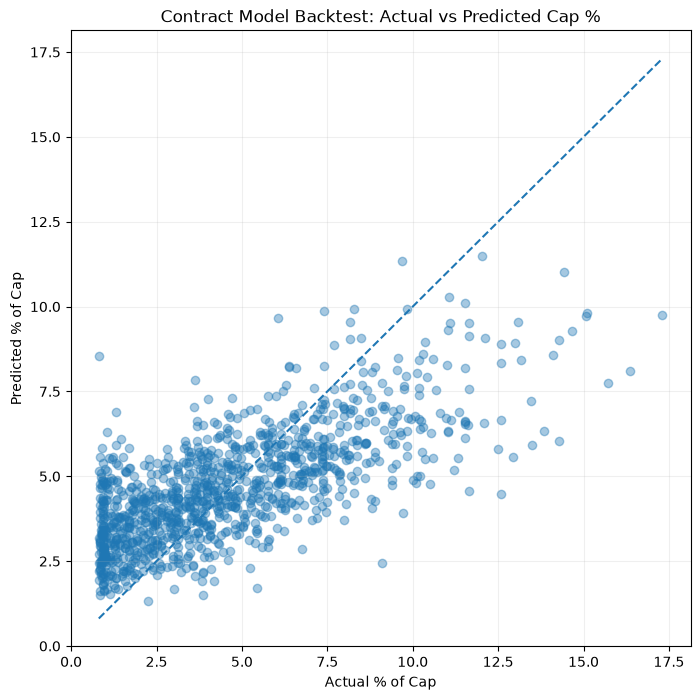

In [66]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

plt.scatter(
    backtest["actual_cap_pct"],
    backtest["predicted_cap_pct"],
    alpha=0.4
)

lims = [
    min(backtest["actual_cap_pct"].min(), backtest["predicted_cap_pct"].min()),
    max(backtest["actual_cap_pct"].max(), backtest["predicted_cap_pct"].max())
]

plt.plot(lims, lims, "--")

plt.xlabel("Actual % of Cap")
plt.ylabel("Predicted % of Cap")
plt.title("Contract Model Backtest: Actual vs Predicted Cap %")
plt.grid(alpha=0.2)

plt.show()

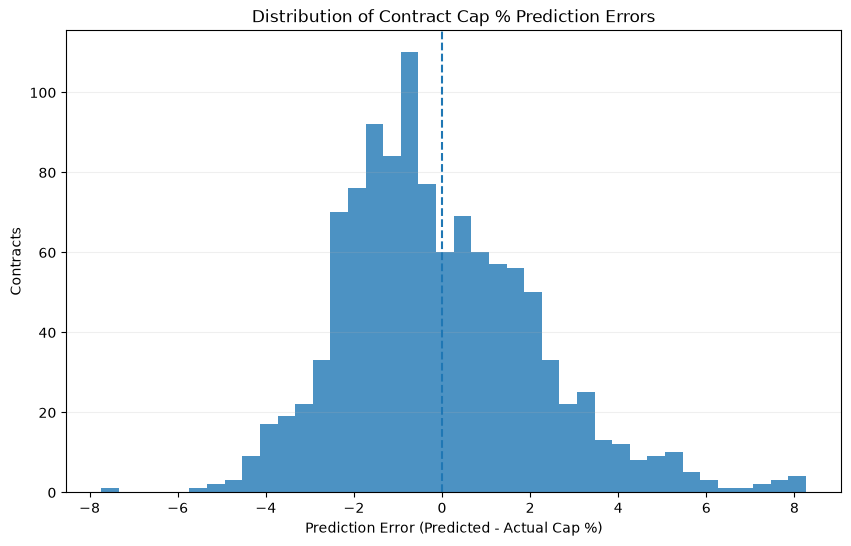

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(
    backtest["cap_pct_error"].dropna(),
    bins=40,
    alpha=0.8
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (Predicted - Actual Cap %)")
plt.ylabel("Contracts")
plt.title("Distribution of Contract Cap % Prediction Errors")
plt.grid(axis="y", alpha=0.2)

plt.show()

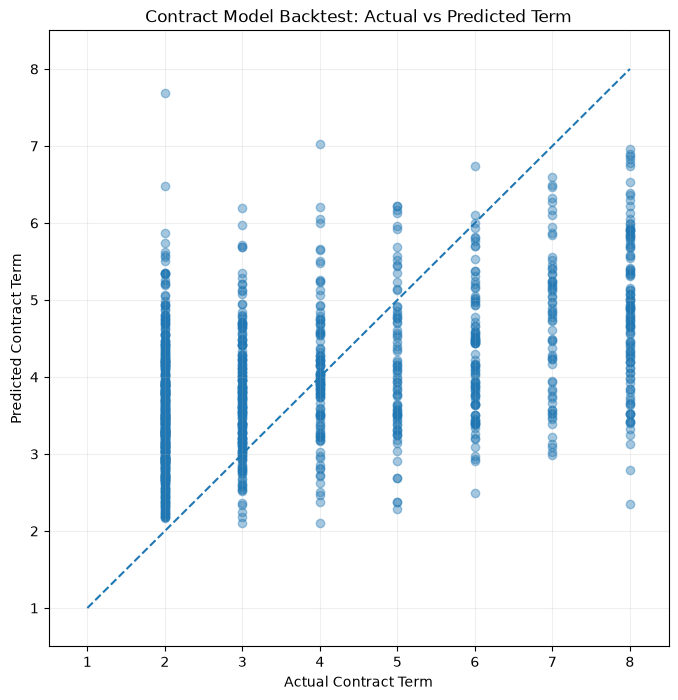

In [68]:
plt.figure(figsize=(8, 8))

plt.scatter(
    backtest["actual_term"],
    backtest["predicted_term"],
    alpha=0.4
)

plt.plot([1, 8], [1, 8], "--")

plt.xlim(0.5, 8.5)
plt.ylim(0.5, 8.5)

plt.xlabel("Actual Contract Term")
plt.ylabel("Predicted Contract Term")
plt.title("Contract Model Backtest: Actual vs Predicted Term")
plt.grid(alpha=0.2)

plt.show()

In [89]:
spec = importlib.util.spec_from_file_location(
    "overall",
    "06_overall.py"
)

overall = importlib.util.module_from_spec(spec)
spec.loader.exec_module(overall)

In [90]:
overall.find_overall_comparables(8484153,20)

,rank,playerId,player,position,current_aav,current_contract_term,current_contract_to,current_contract_cap_pct,overall_similarity,playing_style_similarity,playing_style_rank,production_similarity,production_rank,effectiveness_similarity,effectiveness_rank,usage_similarity,usage_rank,trajectory_similarity,trajectory_rank,models_available
0,1,8476459,Mika Zibanejad,C,8500000,8,2029-30,10.30,59.731099,59.855274,4,83.445494,1,36.855669,116,74.037652,7,44.461408,17,5
1,2,8478401,Pavel Zacha,C,4750000,4,2026-27,5.69,55.507206,48.641466,32,75.189253,7,46.183526,43,77.288447,6,30.233338,75,5
2,3,8477935,Sam Bennett,C,8000000,8,2032-33,8.38,55.075097,43.666466,54,58.420549,17,45.237874,47,81.557074,4,46.493525,14,5
3,4,8482665,Matty Beniers,C,<NA>,<NA>,NaN,NaN,54.186189,58.641477,5,29.359262,74,52.604778,16,88.701200,2,41.624229,23,5
4,5,8482116,Tim Stützle,C,<NA>,<NA>,NaN,NaN,54.168552,50.897551,24,77.464951,4,56.773329,10,44.494071,64,41.212860,25,5
5,6,8478427,Sebastian Aho,C,9750000,8,2031-32,11.08,54.095096,65.191942,2,60.787308,14,39.109384,92,77.737951,5,27.648897,89,5
6,7,8481533,Trevor Zegras,C,9125000,4,2029-30,8.77,52.829903,42.303412,60,60.496594,15,58.422668,7,34.808622,90,68.118217,1,5
7,8,8483493,Frank Nazar,C,6599991,7,2032-33,6.35,52.438733,63.307188,3,33.159658,61,49.425932,29,82.967147,3,33.333739,61,5
8,9,8479420,Tage Thompson,C,7142857,7,2029-30,8.55,52.169846,47.810723,37,72.856316,9,41.278780,74,69.048249,11,29.855164,79,5
9,10,8484144,Connor Bedard,C,15000000,5,2030-31,14.42,51.724220,39.524583,83,75.284916,6,47.151680,38,45.937928,60,50.721991,7,5
